In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
df = pd.read_csv("data_for_ml.csv")
df.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,Male,Self Study,75.0,55.0
1,3.0,7.0,2.0,Female,Coaching,80.0,60.0
2,4.0,6.0,4.0,male,Self study,78.0,62.0
3,5.0,8.0,3.0,Femle,Group Study,85.0,70.0
4,6.0,7.0,5.0,Male,Self Study,88.0,72.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   56 non-null     float64
 1   Sleep_Hours     56 non-null     float64
 2   Internet_Usage  56 non-null     float64
 3   Gender          56 non-null     object 
 4   Study_Method    56 non-null     object 
 5   Attendance      56 non-null     float64
 6   Final_Score     56 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.2+ KB


In [4]:
df.isnull().sum()

Hours_Studied     1
Sleep_Hours       1
Internet_Usage    1
Gender            1
Study_Method      1
Attendance        1
Final_Score       1
dtype: int64

In [19]:
# Fill numeric columns (including Final_Score)
df = df.copy()
df = df.fillna(df.mean(numeric_only=True))

# Drop any remaining NaN rows (SAFE FINAL STEP)
df = df.dropna().copy()

In [20]:
df = df.drop_duplicates().copy()

In [21]:
le = LabelEncoder()

df.loc[:, 'Gender'] = le.fit_transform(df['Gender'])
df.loc[:, 'Study_Method'] = le.fit_transform(df['Study_Method'])

df.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,2,3,75.0,55.0
1,3.0,7.0,2.0,0,0,80.0,60.0
2,4.0,6.0,4.0,3,4,78.0,62.0
3,5.0,8.0,3.0,1,1,85.0,70.0
4,6.0,7.0,5.0,2,3,88.0,72.0


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop("Final_Score", axis=1))

df_scaled = pd.DataFrame(X_scaled, columns=df.columns[:-1])
df_scaled['Final_Score'] = df['Final_Score'].values  # ensure alignment

# Final safety check (IMPORTANT)
print(df_scaled.isnull().sum())

Hours_Studied     0
Sleep_Hours       0
Internet_Usage    0
Gender            0
Study_Method      0
Attendance        0
Final_Score       0
dtype: int64


In [23]:
features = [
    "Hours_Studied",
    "Sleep_Hours",
    "Internet_Usage",
    "Study_Method",
    "Attendance"
]

MSE: 16.333391984929055
R2: 0.8774995601130321


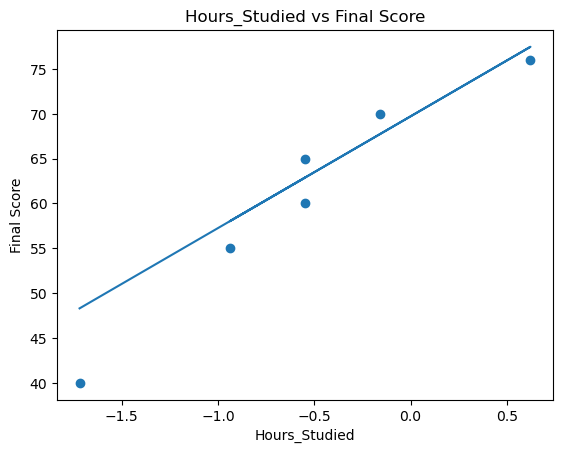

In [24]:
feature = "Hours_Studied"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

MSE: 48.75497319727481
R2: 0.634337701020439


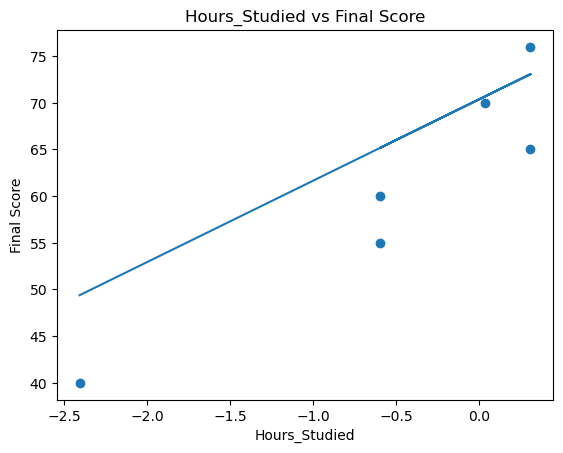

In [25]:
feature = "Sleep_Hours"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

MSE: 66.82614068947203
R2: 0.49880394482895984


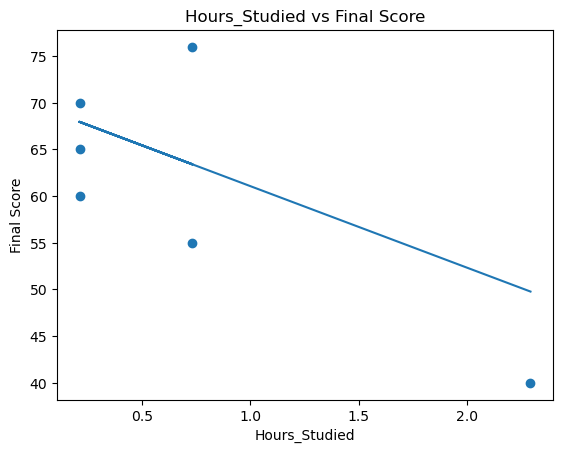

In [26]:
feature = "Internet_Usage"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

MSE: 261.5790318265765
R2: -0.9618427386993238


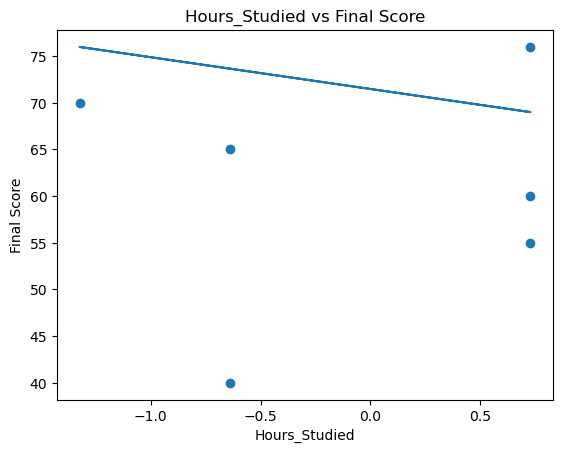

In [27]:
feature = "Study_Method"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

MSE: 17.699945624809054
R2: 0.867250407813932


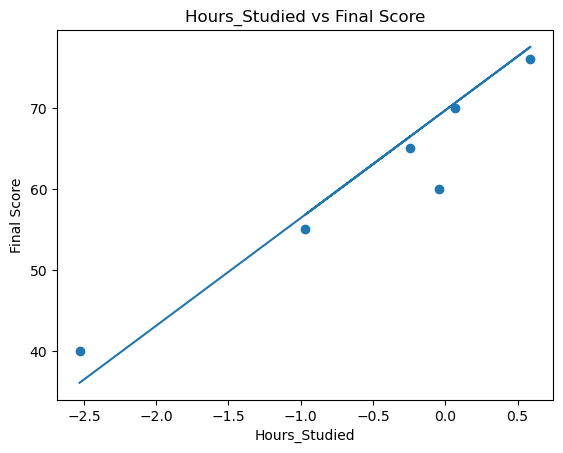

In [28]:
feature = "Attendance"

X = df_scaled[[feature]]
y = df_scaled["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Hours_Studied vs Final Score")
plt.xlabel("Hours_Studied")
plt.ylabel("Final Score")
plt.show()

In [29]:
print("Dataset Shape:", df.shape)
print("Any Missing Values Left?\n", df.isnull().sum())

Dataset Shape: (30, 7)
Any Missing Values Left?
 Hours_Studied     0
Sleep_Hours       0
Internet_Usage    0
Gender            0
Study_Method      0
Attendance        0
Final_Score       0
dtype: int64
